<a href="https://colab.research.google.com/github/w4ib4/AI-and-Machine-Learning/blob/main/SrijanTamang_Worksheet_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI Datasets/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/AI Datasets"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print(os.listdir(extract_path))

Unzipped successfully!
['mnist_dataset.csv', 'mnist_0_and_1.csv', 'mnist_3_and_5.csv', 'Copy of devnagari digit.zip', 'brokenleg.jpg', 'car.jpg', 'workshop4', 'FruitinAmazon.zip', 'FruitinAmazon']


In [4]:
for root, dirs, files in os.walk("/content/drive/MyDrive/AI Datasets/FruitinAmazon"):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files[:5])
    print("-" * 50)

ROOT: /content/drive/MyDrive/AI Datasets/FruitinAmazon
DIRS: ['test', 'train']
FILES: []
--------------------------------------------------
ROOT: /content/drive/MyDrive/AI Datasets/FruitinAmazon/test
DIRS: ['cupuacu', 'acai', 'pupunha', 'graviola', 'tucuma', 'guarana']
FILES: []
--------------------------------------------------
ROOT: /content/drive/MyDrive/AI Datasets/FruitinAmazon/test/cupuacu
DIRS: []
FILES: ['download (5).jpeg', 'download (3).jpeg', 'download (2).jpeg', 'images (3).jpeg', 'download (4).jpeg']
--------------------------------------------------
ROOT: /content/drive/MyDrive/AI Datasets/FruitinAmazon/test/acai
DIRS: []
FILES: ['images (2).jpeg', 'images (16).jpeg', 'images.jpeg', 'download (9).jpeg', 'images (17).jpeg']
--------------------------------------------------
ROOT: /content/drive/MyDrive/AI Datasets/FruitinAmazon/test/pupunha
DIRS: []
FILES: ['download (2).jpeg', 'download (1).jpeg', 'download (11).jpeg', 'download (4).jpeg', 'download (3).jpeg']
-----------

In [5]:
train_dir = "/content/drive/MyDrive/AI Datasets/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI Datasets/FruitinAmazon/test"

class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [6]:
sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random_image = random.choice(image_files)
    sample_images.append((class_name, os.path.join(class_path, random_image)))

print(sample_images)

[('acai', '/content/drive/MyDrive/AI Datasets/FruitinAmazon/train/acai/images (15).jpeg'), ('cupuacu', '/content/drive/MyDrive/AI Datasets/FruitinAmazon/train/cupuacu/images.jpeg'), ('graviola', '/content/drive/MyDrive/AI Datasets/FruitinAmazon/train/graviola/images (5).jpeg'), ('guarana', '/content/drive/MyDrive/AI Datasets/FruitinAmazon/train/guarana/download (10).jpeg'), ('pupunha', '/content/drive/MyDrive/AI Datasets/FruitinAmazon/train/pupunha/download.jpeg'), ('tucuma', '/content/drive/MyDrive/AI Datasets/FruitinAmazon/train/tucuma/images (1).jpeg')]


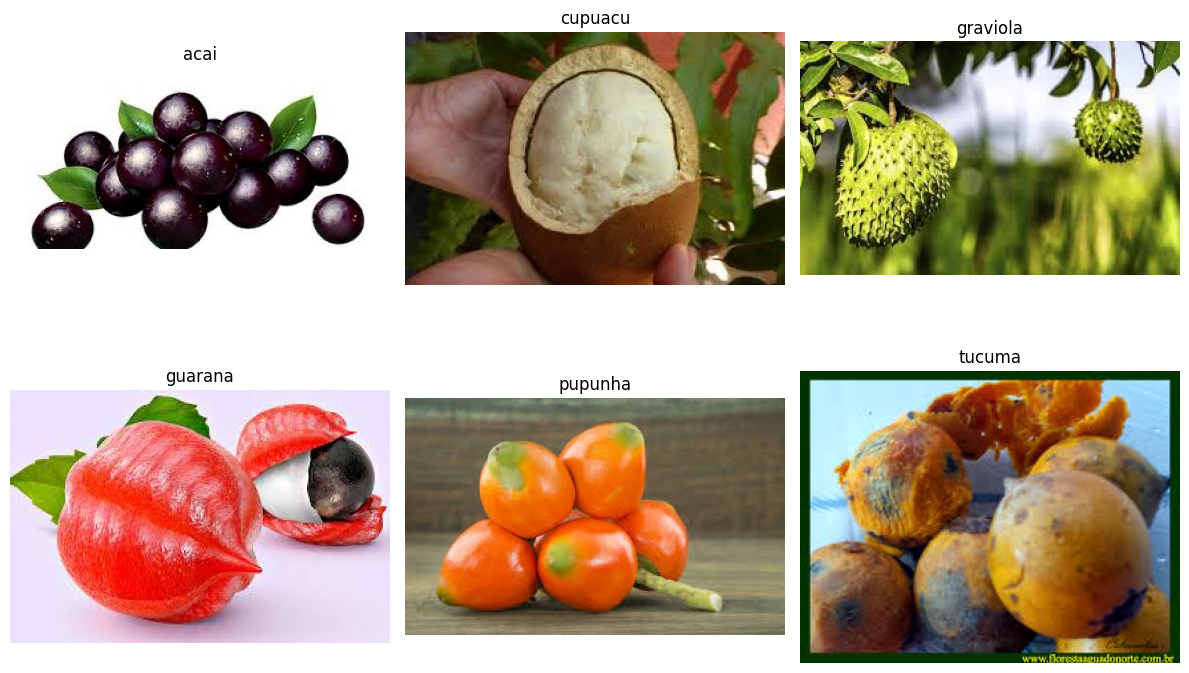

In [7]:
plt.figure(figsize=(12, 8))

rows = 2
cols = 3

for i, (class_name, image_path) in enumerate(sample_images):
    img = Image.open(image_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
def remove_corrupted_images(directory):
    corrupted_files = []

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception:
                corrupted_files.append(file_path)
                os.remove(file_path)
                print("Removed corrupted image:", file_path)

    if not corrupted_files:
        print("No Corrupted Images Found.")

    return corrupted_files

In [9]:
print("Checking train folder...")
train_corrupted = remove_corrupted_images(train_dir)

print("\nChecking test folder...")
test_corrupted = remove_corrupted_images(test_dir)

Checking train folder...
No Corrupted Images Found.

Checking test folder...
No Corrupted Images Found.


In [10]:
print("Checking train folder...")
train_corrupted = remove_corrupted_images(train_dir)

print("\nChecking test folder...")
test_corrupted = remove_corrupted_images(test_dir)

Checking train folder...
No Corrupted Images Found.

Checking test folder...
No Corrupted Images Found.


In [11]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

In [12]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [13]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [14]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


In [15]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [16]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [18]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_fruit_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [22]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.1233 - loss: 2.0003
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 342ms/step - accuracy: 0.1111 - loss: 1.9717 - val_accuracy: 0.0556 - val_loss: 1.9418
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.2767 - loss: 1.7916
Epoch 2: val_accuracy improved from 0.05556 to 0.83333, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.2639 - loss: 1.7107 - val_accuracy: 0.8333 - val_loss: 1.4733
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.3865 - loss: 1.5706
Epoch 3: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.3750 - loss: 1.5076 - val_accuracy: 0.7222 - val_loss: 1.3402
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.4247 - loss: 1.3458
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.4722 - loss: 1.2749 - val_accuracy: 0.6667 - val_loss: 1.1242
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.5781 - loss: 1.0624
Epoch 5: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 279ms/step - accuracy: 0.6667 - loss: 0.9714 - val_accuracy: 0.5556 - val_loss: 0.8880
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.7389 - loss:


Epoch 10: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 0.9861 - loss: 0.0928 - val_accuracy: 0.8889 - val_loss: 0.7520
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9712 - loss: 0.1179
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - accuracy: 0.9861 - loss: 0.0775 - val_accuracy: 0.5556 - val_loss: 1.7913
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9410 - loss: 0.2626
Epoch 12: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - accuracy: 0.9444 - loss: 0.2204 - val_accuracy: 0.7778 - val_loss: 1.1270
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.8118 - loss: 0.5142
Epoch 13: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.8611 - loss: 0.3334 - val_accuracy: 0.7778 - val_loss: 0.8982
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8806


Epoch 14: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 524ms/step - accuracy: 0.8611 - loss: 0.3126 - val_accuracy: 0.9444 - val_loss: 0.2300
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9913 - loss: 0.0786
Epoch 15: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.9722 - loss: 0.1029 - val_accuracy: 0.8333 - val_loss: 0.4469
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9941 - loss: 0.0834
Epoch 16: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 255ms/step - accuracy: 0.9861 - loss: 0.0806 - val_accuracy: 0.8333 - val_loss: 0.7029
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 1.0000 - loss: 0.0451
Epoch 17: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 1.0000 - loss: 0.0347 - val_accuracy: 0.8889 - val_loss: 0.4177
Epoch 18/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 1.0000

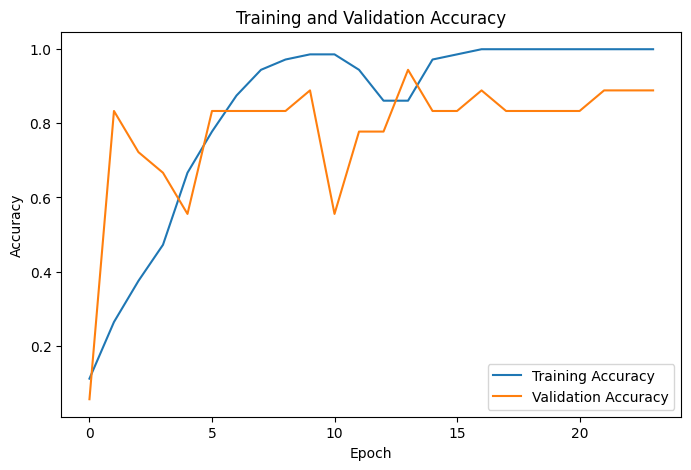

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

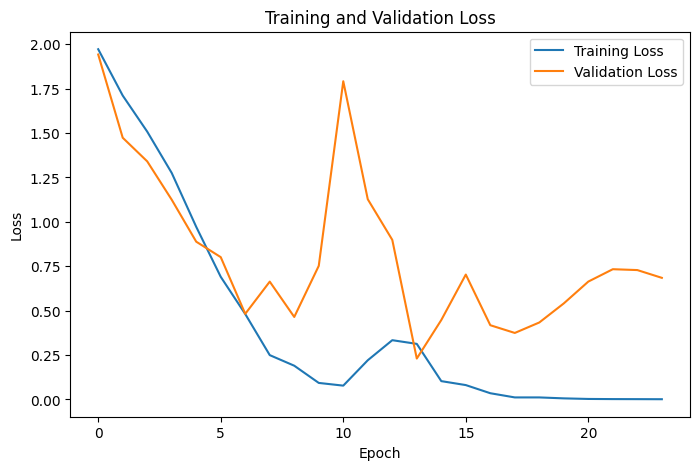

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [25]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6667 - loss: 1.0060
Test Loss: 1.0060447454452515
Test Accuracy: 0.6666666865348816


In [26]:
model.save("fruit_classifier_final.h5")
print("Model saved successfully.")

Model saved successfully.


In [27]:
loaded_model = tf.keras.models.load_model("fruit_classifier_final.h5")
print("Model loaded successfully.")

Model loaded successfully.


In [28]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.6667 - loss: 1.0060
Loaded Model Test Loss: 1.0060447454452515
Loaded Model Test Accuracy: 0.6666666865348816


In [29]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [30]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.50      0.40      0.44         5
    graviola       0.62      1.00      0.77         5
     guarana       0.83      1.00      0.91         5
     pupunha       0.67      0.40      0.50         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.67        30
   macro avg       0.65      0.67      0.64        30
weighted avg       0.65      0.67      0.64        30



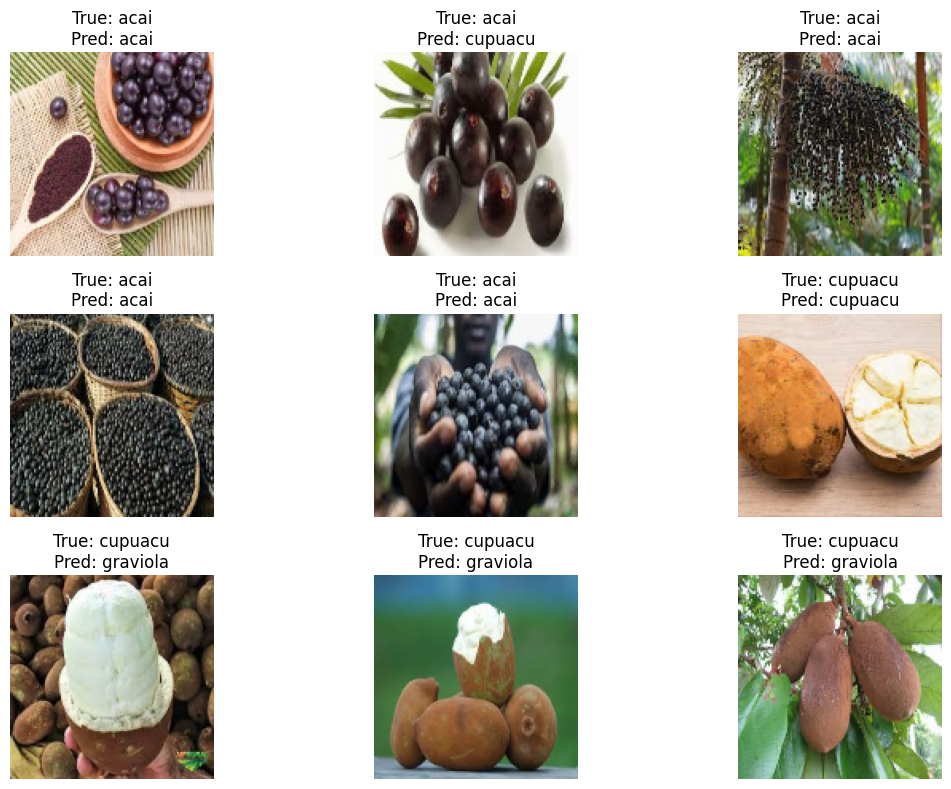

In [31]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted_labels[i]]}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
import os

if os.path.exists("fruit_classifier_final.h5"):
    print("Model file exists.")
    print("File name:", "fruit_classifier_final.h5")
    print("File size:", os.path.getsize("fruit_classifier_final.h5"), "bytes")
else:
    print("Model file not found.")

Model file exists.
File name: fruit_classifier_final.h5
File size: 25442992 bytes


In [33]:
loaded_model = tf.keras.models.load_model("fruit_classifier_final.h5")
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,456 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)